# Neighbor LCOE outliers

Explores sites whose **total LCOE** is unusual compared to **other sites within a radius** (and optional same country / sector), using metrics from `utils/analysis/neighbor_lcoe_contrast.py`.

**Regenerate metrics** (from repo root):

```bash
python flatblock_optimization/utils/analysis/neighbor_lcoe_contrast.py \
  --combined-csv flatblock_optimization/outputs/combined_results_all_sites_v1.csv \
  --radius-km 80 --same-country-only --sector power --min-neighbors 4 \
  --sort-by abs_z --min-abs-z 5

Use **thresholds** (`--min-abs-z`, `--min-ratio-median`, `--min-ratio-mean`) instead of `--top`. With a threshold, all matching rows print (optional `--top N` caps). With no threshold, the script defaults to printing 50 rows (same as `--top 50`).
```

That writes `flatblock_optimization/outputs/combined_results_all_sites_v1_neighbor_lcoe.csv` with `neighbor_mean_lcoe`, `lcoe_z_vs_neighbors`, `ratio_to_neighbor_median`, etc.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root: cwd may be repo, flatblock_optimization, or notebooks/
_here = Path.cwd().resolve()
if _here.name == "notebooks":
    REPO = _here.parent.parent
elif _here.name == "flatblock_optimization":
    REPO = _here.parent
else:
    REPO = _here

OUT_DIR = REPO / "flatblock_optimization" / "outputs"
COMBINED = OUT_DIR / "combined_results_all_sites_v1.csv"
ENRICHED = OUT_DIR / "combined_results_all_sites_v1_neighbor_lcoe.csv"

LCOL = "LCOE_total_$perMWh"

In [6]:
df = pd.read_csv(COMBINED)
en = pd.read_csv(ENRICHED)
assert len(df) == len(en), "Re-run neighbor_lcoe_contrast.py so row counts match"
print(f"{len(df):,} sites in combined + enriched tables")
en.head(2)

43,679 sites in combined + enriched tables


,site,load_MW,S_opt_MW,Battery_capacity_MW,Battery_energy_MWh,LCOE_total_$perMWh,LCOE_solar_$perMWh,LCOE_batt_$perMWh,LCOE_unserved_$perMWh,Reliability_%,...,neighbor_median_lcoe,neighbor_std_lcoe,ratio_to_neighbor_median,ratio_to_neighbor_mean,lcoe_z_vs_neighbors,abs_z_vs_neighbors,outlier_rank_score,ratio_to_cheapest_neighbor,cheapest_neighbor_source_id,distance_km_to_cheapest_neighbor
0,25454443,100,529.592506,236.458341,1418.750045,74.544310,27.283513,47.260797,0.0,90.0,...,74.557878,NaN,0.999818,0.999818,-0.009099,0.009099,0.009099,0.999818,25454442.0,37.539640
1,25454888,100,560.527334,237.884047,1427.304283,76.422964,28.877212,47.545752,0.0,90.0,...,75.371531,1.553978,1.013950,1.006354,0.310528,0.310528,0.310528,1.017927,25451021.0,42.958414


## Local outliers (threshold on |z| vs neighbor set)

Set **`MIN_ABS_Z`** (and optionally **`MIN_RATIO_MEDIAN`**, **`TOP_CAP`**) instead of a fixed “top N”. Requires finite `lcoe_z_vs_neighbors`.

In [7]:
MIN_ABS_Z = 5.0  # |z| vs neighbor mean; set None to skip this filter
MIN_RATIO_MEDIAN = None  # e.g. 1.8 — focal LCOE / neighbor median LCOE
MIN_LCOE_GAP = None  # optional: min (focal $/MWh − neighbor median $/MWh), e.g. 50.0
MIN_NEIGHBORS = 4
SECTOR = "power"  # or None for all sectors
TOP_CAP = None  # optional max rows after filters (None = keep all)

sub = en.dropna(subset=["lcoe_z_vs_neighbors"]).copy()
sub = sub[sub["n_neighbors_in_radius"] >= MIN_NEIGHBORS]
if SECTOR:
    sub = sub[sub["sector"].astype(str) == SECTOR]

if MIN_ABS_Z is not None:
    sub = sub[sub["abs_z_vs_neighbors"] >= MIN_ABS_Z]
if MIN_RATIO_MEDIAN is not None:
    sub = sub[sub["ratio_to_neighbor_median"] >= MIN_RATIO_MEDIAN]
if MIN_LCOE_GAP is not None:
    gap = sub[LCOL] - sub["neighbor_median_lcoe"]
    sub = sub[gap >= MIN_LCOE_GAP]

sub = sub.sort_values("abs_z_vs_neighbors", ascending=False)
if TOP_CAP is not None:
    sub = sub.head(TOP_CAP)
top = sub
cols = [
    "source_id",
    "iso3_country",
    "lat",
    "lon",
    "sector",
    "source_type",
    LCOL,
    "n_neighbors_in_radius",
    "neighbor_median_lcoe",
    "neighbor_mean_lcoe",
    "ratio_to_neighbor_median",
    "lcoe_z_vs_neighbors",
    "abs_z_vs_neighbors",
]
cols = [c for c in cols if c in top.columns]
top[cols]

,source_id,iso3_country,lat,lon,sector,source_type,LCOE_total_$perMWh,n_neighbors_in_radius,neighbor_median_lcoe,neighbor_mean_lcoe,ratio_to_neighbor_median,lcoe_z_vs_neighbors,abs_z_vs_neighbors
27846,4407770,GBR,52.7573,-1.2801,power,biomass,392.879793,83,123.670427,124.428696,3.176829,69.430321,69.430321
29852,449890,ESP,43.3590,-3.0921,power,"gas, other_fossil",243.264704,26,87.481632,88.893100,2.780752,25.510642,25.510642
3561,4403952,SWE,56.8678,14.8356,power,biomass,247.066174,4,182.753972,181.721746,1.351906,17.979254,17.979254
22825,4402499,JPN,35.0780,135.0592,power,biomass,122.019254,54,88.024272,88.160273,1.386200,12.770986,12.770986
6121,452361,RUS,59.6048,33.4856,power,gas,1285.449248,6,759.329618,751.179018,1.692874,8.642342,8.642342
5009,448243,HRV,46.0388,16.1814,power,"gas, other_fossil",133.373148,5,115.201739,113.993214,1.157736,8.500477,8.500477
17574,25457035,USA,61.4595,-149.3406,power,gas,2028.848895,23,359.184431,442.049219,5.648488,7.687601,7.687601
2003,25450346,ITA,46.4070,12.9386,power,"gas, other_fossil",156.373903,15,91.148364,94.572147,1.715597,7.198574,7.198574
14833,38757140,FIN,62.5934,29.8372,power,biomass,656.513976,4,765.668590,764.637798,0.857439,-7.070264,7.070264


## Map: where are the outliers?

Scatter of focal sites (not neighbors). Color = |z|.

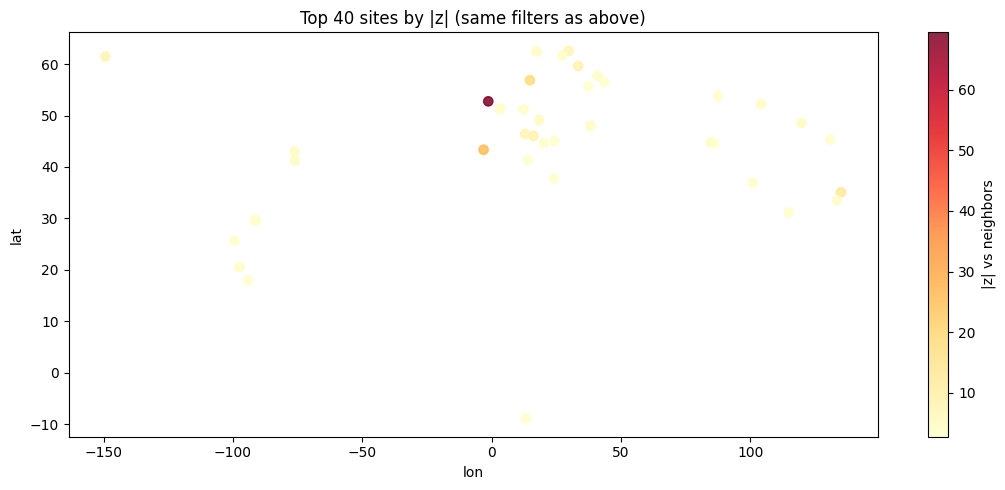

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
t = top.dropna(subset=["lat", "lon", "abs_z_vs_neighbors"])
sc = ax.scatter(t["lon"], t["lat"], c=t["abs_z_vs_neighbors"], cmap="YlOrRd", s=45, alpha=0.85)
plt.colorbar(sc, ax=ax, label="|z| vs neighbors")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title(f"Top {len(t)} sites by |z| (same filters as above)")
plt.tight_layout()
plt.show()

## Technology mix (`source_type`) among top outliers

Large |z| often reflects a focal site with unusual **technology** vs local peers (e.g. biomass vs gas).

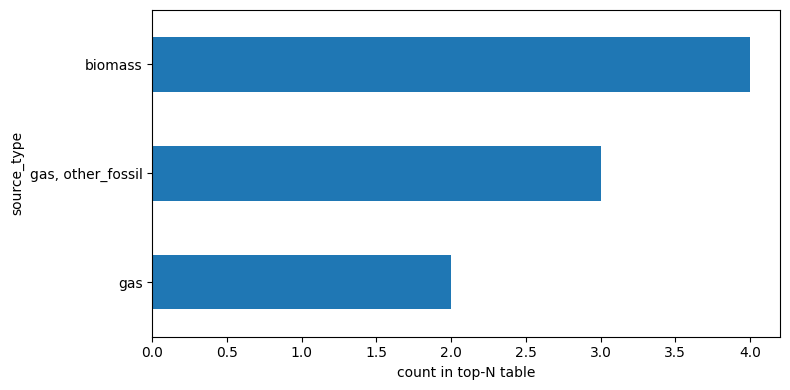

In [8]:
if "source_type" in top.columns:
    vc = top["source_type"].fillna("(missing)").value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    vc.head(15).plot(kind="barh", ax=ax)
    ax.set_xlabel("count in top-N table")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Focal LCOE vs neighbor median (top table)

Points above the diagonal are more expensive than the **median** neighbor LCOE in radius.

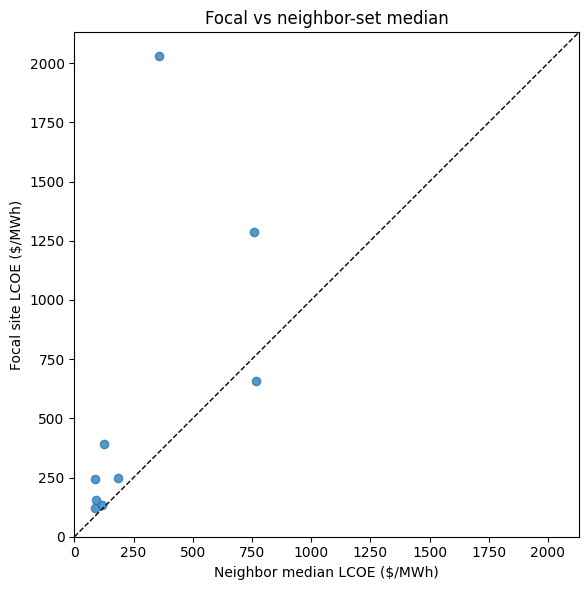

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
x = top["neighbor_median_lcoe"]
y = top[LCOL]
ax.scatter(x, y, alpha=0.75)
lim = 0, max(x.max(), y.max()) * 1.05
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Neighbor median LCOE ($/MWh)")
ax.set_ylabel("Focal site LCOE ($/MWh)")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Focal vs neighbor-set median")
plt.tight_layout()
plt.show()

## Export `source_id` list for follow-up

Paste into other tools or facility lookups.

In [10]:
ids = top["source_id"].astype(int).tolist()
print(ids)

[4407770, 449890, 4403952, 4402499, 452361, 448243, 25457035, 25450346, 38757140]
